In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Bonus practice: matplotlib & numpy 

## HadCRUT5 Global Temperature Change
To practice some of the matplotlib and numpy skills we learned, let's take a look at yearly and smoothed time series of globally averaged temperature anomalies derived from the HadCRUT5 dataset.

- Data source: https://crudata.uea.ac.uk/cru/info/warming/gtc.csv
- Dataset: HadCRUT5 (Morice et al., 2021)
- Variables:
  1. Yearly global temperature anomaly compared to 1961-1990 baseline
  2. Smoothed anomaly
- Units: °C
- Time: 1850 - 2023 (yearly values)
- Format:

| Year | Anomaly | Smoothed|
| :--: | :-------|  :----- |
| 1850 | -0.418  | -0.31   |

First, we'll load in the data using `np.loadtxt`.

In [2]:
crudata_path = "../../data/global-temperature-change_hadcrut5.csv"
# load the dataset  
gt_year, gt_anomaly, gt_smooth = np.loadtxt(crudata_path, skiprows=2, 
                                            delimiter=",", unpack=True)

In [3]:
np.loadtxt(crudata_path, skiprows=2, delimiter=",", unpack=True).shape

(3, 174)

## Exercise 1: Use numpy to get to know the data!

a) First, what are the types and shapes of `gt_year`, `gt_anomaly` and `gt_smooth`? 

Which period does the time series cover? 

In [4]:
print("gt_year has type ", type(gt_year), "and shape ", gt_year.shape)
print("gt_anomaly has type ", type(gt_anomaly), "and shape ", gt_anomaly.shape)
print("gt_smooth has type ", type(gt_smooth), "and shape ", gt_smooth.shape)
startyear = gt_year[0]
endyear = gt_year[-1]
print("period covered: {}-{}".format(startyear, endyear))

gt_year has type  <class 'numpy.ndarray'> and shape  (174,)
gt_anomaly has type  <class 'numpy.ndarray'> and shape  (174,)
gt_smooth has type  <class 'numpy.ndarray'> and shape  (174,)
period covered: 1850.0-2023.0


b) The temperature anomaly data is referenced to the 1961-1990 baseline. 
 * What is the mean temperature anomaly prior to 1961?
 * What is the mean temperature anomaly after 1990? 

In [5]:
# Your code here... 
# Hint - create a boolean array to sample the years you are interested in?  
bool_pre61 = gt_year < 1961
bool_aft90 = gt_year > 1990
mean_Tanom_pre61 = np.mean(gt_anomaly[bool_pre61])
mean_Tanom_aft90 = np.mean(gt_anomaly[bool_aft90])
print(f"The mean temperature anomaly is {mean_Tanom_pre61} "\
      f"prior to 1961 and {mean_Tanom_aft90} after 1990.")

The mean temperature anomaly is -0.2862072072072072 prior to 1961 and 0.5753333333333335 after 1990.


c) 2023 was the warmest year on record - which year was the second warmest? 

In [6]:
# Hint - find the maximum value before 2023? Which index contains that maximum value? 
max_anom = np.max(gt_anomaly[:-1])
second_warmest_year = gt_year[gt_anomaly == max_anom]
print(f"the second warmest year was {int(second_warmest_year.item())}, with an anomaly of +{max_anom} °C")

the second warmest year was 2016, with an anomaly of +0.933 °C


d) How many years has the temperature anomaly exceeded 0.5°C? 

In [7]:
exceed_05_bool = gt_anomaly > 0.5
n_years = np.sum(exceed_05_bool)
print(f"{n_years} years exceeded a temperature anomaly of 0.5°C")

21 years exceeded a temperature anomaly of 0.5°C


e) BONUS exercise: How many years since 1995 were the hottest on record at the time?

In [8]:
# there are multiple ways you can approach this! 
y_warmest = []
for year in np.arange(1995, endyear+1):
    anom_to_y = gt_anomaly[gt_year <= year]
    if gt_year[gt_anomaly == np.max(anom_to_y)] == year:
        y_warmest.append(int(year))
n_warmest = len(y_warmest)
print(f"{n_warmest} years since 1995 were the warmest at the time: {y_warmest}")

8 years since 1995 were the warmest at the time: [1995, 1997, 1998, 2005, 2010, 2015, 2016, 2023]


## Exercise 2: Matplotlib

The following graph is a screen shot from an earlier version of the published dataset info sheet. 

Let's try to create an updated version, to include the recent maximum in 2023. 

![](../../figures/HadCRUT5_globtemp_infosheet.png)

Positive yearly temperature anomalies are plotted in red, negative anomalies in blue. 

As an extra challenge, use the useful function [`numpy.where()`](https://numpy.org/doc/stable/reference/generated/numpy.where.html) to isolate positive and negative anomalies:

`numpy.where(condition, value for True positions, value for False positions)`

The result should be 2 1D numpy arrays with only the positive (negative) values, and 0 or np.nan ("not a number") on the positions of the negative (positive) values. 


<i>Click "details" for a solution to proceed to plotting: </i>
<details>

    gt_neg_anomaly = np.where(gt_anomaly < 0, gt_anomaly, np.nan) 
    gt_pos_anomaly = np.where(gt_anomaly > 0, gt_anomaly, np.nan) 

</details> 

In [9]:
gt_pos_anomaly = np.where(gt_anomaly > 0, gt_anomaly, np.nan)
gt_neg_anomaly = np.where(gt_anomaly < 0, gt_anomaly, np.nan)

That's all the processing we need, the data is ready to plot! Now, let's dissect the CRU graph in order to recreate it. These are all the elements on the figure that we need to have there:
- One ax / plotting area
- Bar plots with specific colors for positive and negative temperature anomalies
- A thick black line plot overlaying the bars
- Major and minor ticks (pay attention to the intervals)
- A horizontal line for a temperature anomaly of 0°C
- Some text in the upper left corner
- Labels for the ticks of the X and Y axis (pay attention to the intervals).
- Label for the Y axis

When you are done, save the figure to a high resolution (300 dots per inch) png file. Good luck! 



<b>hint 1:</b> Take a look back to [notebook 15-Matplotlib](15-Matplotlib.ipynb) to find out which functions you may need to plot lines and bars, adjust ticks and their labels, put labels and text on your plot, create a figure and save the figure.

<b>hint 2:</b> Optionally, you can use [axhline](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axhline.html).

<b>hint 3:</b> There are different ways to get a bit of text on a graph. [Annotate](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.annotate.html) is one option, [text](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.text.html) is another one. 

In [10]:
# set font size and color for matplotlib text
plt.rcParams["font.size"] = "20"

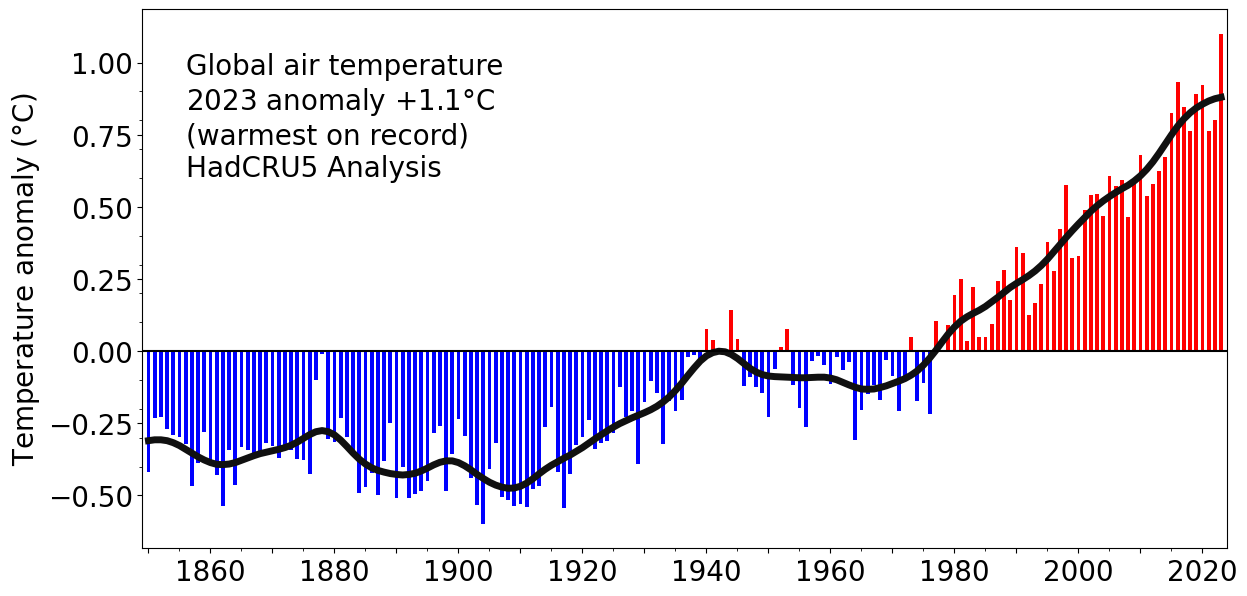

In [11]:
fig, ax = plt.subplots(figsize=(14,7))

# bar plot of positive and negative anomalies
ax.bar(gt_year, gt_neg_anomaly, color='#0000ff', width=0.6)  # hex color format: "#RRGGBB"
ax.bar(gt_year, gt_pos_anomaly, color='#ff0000', width=0.6)

# line plot of smoothed temperature anomalies
ax.plot(gt_year, gt_smooth, linewidth=5, c='#101010')  

# 0 anomaly line
ax.axhline(0, c="#000000")

# set x axis limits
ax.set_xlim([1849, 2024])

# set locations of major and minor x axis ticks every 10/5 years
majorticks = np.arange(1850, 2024, 10)
ax.set_xticks(majorticks)
ax.set_xticks(np.arange(1855, 2024, 10), minor=True)

# set minor ticks for the y axis
ax.set_yticks(np.arange(-0.5, 1, 0.1), minor=True)

# set x axis tick labels only every 20 years to make plot less busy
ax.set_xticklabels(np.where(majorticks%20==0, majorticks, None))

# set y axis label
ax.set_ylabel("Temperature anomaly ($\degree$C)")

# add some text in the upper left corner. use "\n" for new lines. 
ax.text(0.04, 0.92,
        "Global air temperature \n" + f"2023 anomaly +{np.max(gt_anomaly)}$\degree$C \n" +
        "(warmest on record) \n" + "HadCRU5 Analysis", 
        transform=ax.transAxes, va="top", ha="left");

# save the figure
plt.savefig("../../figures/my-global-temperature-plot.png", 
            dpi=300,               # high resolution suited for publication
            bbox_inches="tight")   # remove white border

# References
1. CRU temperature data: <br>
   Morice, C.P., Kennedy, J.J., Rayner, Winn, J.P., Hogan, E., Killick, R.E., Dunn, R.J.H., Osborn, T.J., Jones, P.D., and Simpson, I.R., 2021: An updated assessmentof near-surface temperature change from 1850: the HadCRUT5 dataset. Journal of Geophysical Research, https://doi.org/10.1029/2019JD032361